In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, precision_score, recall_score

# Original dataset:

In [2]:
df_train = pd.read_csv(r'../datasets/preprocessed/KDD_train_preprocessed.csv')
df_test = pd.read_csv(r'../datasets/preprocessed/KDD_test_preprocessed.csv')

y_train = df_train['attack']
X_train = df_train.drop(labels= 'attack', axis= 1).copy()

y_test = df_test['attack']
X_test = df_test.drop(labels= 'attack', axis= 1).copy()

In [3]:
all_classes = np.union1d(np.unique(y_train), np.unique(y_test))
N_CLASSES   = len(all_classes)
N_FEATURES  = X_train.shape[1]

LABEL_NAME_MAP = {
    0: 'DoS',
    1: 'Normal',
    2: 'Probe',
    3: 'R2L',
    4: 'U2R',
}
CLASS_NAMES = [LABEL_NAME_MAP.get(i, f'Class_{i}') for i in all_classes]

In [4]:
def evaluate(name, y_true, y_hat):

    acc_value = accuracy_score(y_true, y_hat)
    precision = precision_score(y_true, y_hat, average= 'weighted', zero_division= 0)
    recall = recall_score(y_true, y_hat, average= 'weighted', zero_division= 0)
    f1_value = f1_score(y_true, y_hat, average= 'weighted', zero_division= 0)
    f1_mac = f1_score(y_true, y_hat, average= 'macro', zero_division= 0)

    print(f'\n=== {name} ===')

    print(
        f'Accuracy : {acc_value:.4f} | '
        f'Precision : {precision:.4f} | '
        f'Recall : {recall:.4f} | '
        f'Weighted F1 : {f1_value:.4f} | '
        f'Macro F1 : {f1_mac:.4f}'
    )

    print(classification_report(y_true, y_hat, labels= all_classes, target_names= CLASS_NAMES, zero_division= 0))

    cm = confusion_matrix(y_true, y_hat, labels= all_classes)

    fig, ax = plt.subplots(figsize= (6, 5))
    sns.heatmap(cm, annot= True, fmt= 'd', cmap= 'Blues', xticklabels= CLASS_NAMES, yticklabels= CLASS_NAMES, ax= ax)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.show()

    return acc_value, f1_value, f1_mac


RESULTS = {}

## Random forest:

Best params: {'criterion': 'entropy', 'max_depth': 25, 'n_estimators': 43}
Best params: {'criterion': 'entropy', 'max_depth': 25, 'n_estimators': 43}

=== Random Forest ===
Accuracy : 0.7521 | Precision : 0.8206 | Recall : 0.7521 | Weighted F1 : 0.7122 | Macro F1 : 0.4959
              precision    recall  f1-score   support

         DoS       0.96      0.79      0.87      7458
      Normal       0.65      0.97      0.78      9711
       Probe       0.85      0.58      0.69      2421
         R2L       1.00      0.06      0.12      2754
         U2R       1.00      0.01      0.02       200

    accuracy                           0.75     22544
   macro avg       0.89      0.48      0.50     22544
weighted avg       0.82      0.75      0.71     22544



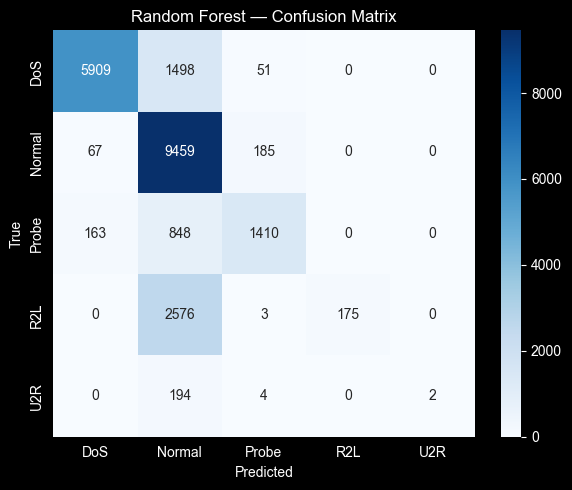

In [5]:
model_rf = RandomForestClassifier(random_state= 42)
random_forest = GridSearchCV(
    estimator= model_rf,
    param_grid= {
        "n_estimators" : [41, 42, 43],
        "criterion" : ['entropy', 'gini', 'log_loss'],
        "max_depth": [25],
    },
    cv= 5,
    scoring= 'f1_macro',
    n_jobs= -1
)

random_forest.fit(X_train, y_train)
print(f'Best params: {random_forest.best_params_}')

y_pred = random_forest.predict(X_test)
print(f'Best params: {random_forest.best_params_}')

label  = f"Random Forest"
acc, f1, macro = evaluate(label, y_test, y_pred)
RESULTS[label] = {'Accuracy': acc, 'F1': f1, 'Macro F1': macro}

Best params: {'C': 68, 'gamma': 'scale', 'kernel': 'linear', 'tol': 0.001}
Best params: {'C': 68, 'gamma': 'scale', 'kernel': 'linear', 'tol': 0.001}

=== SVC ===
Accuracy : 0.7729 | Precision : 0.8059 | Recall : 0.7729 | Weighted F1 : 0.7398 | Macro F1 : 0.5646
              precision    recall  f1-score   support

         DoS       0.89      0.86      0.88      7458
      Normal       0.69      0.93      0.79      9711
       Probe       0.89      0.70      0.78      2421
         R2L       0.93      0.11      0.20      2754
         U2R       0.62      0.10      0.17       200

    accuracy                           0.77     22544
   macro avg       0.80      0.54      0.56     22544
weighted avg       0.81      0.77      0.74     22544



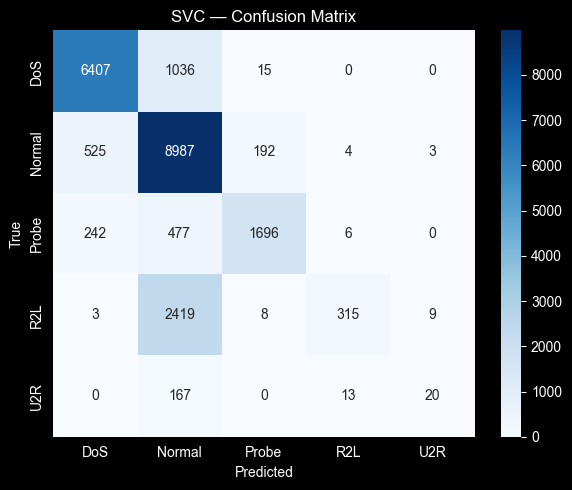

In [6]:
model_svc = SVC()
svc = GridSearchCV(
    estimator= model_svc,
    param_grid= {
        'C': [68, 69, 70],
        'kernel': ['linear'],
        'gamma': ['scale'],
        'tol': [1e-3]
    },
    cv= 5,
    scoring= 'f1_macro',
    n_jobs= -1
)

svc.fit(X_train, y_train)
print(f'Best params: {svc.best_params_}')

y_pred = svc.predict(X_test)
print(f'Best params: {svc.best_params_}')

label  = f"SVC"
acc, f1, macro = evaluate(label, y_test, y_pred)
RESULTS[label] = {'Accuracy': acc, 'F1': f1, 'Macro F1': macro}

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 9, 'min_child_weight': 3, 'n_estimators': 35, 'subsample': 0.8}

=== XGBoost ===
Accuracy : 0.7720 | Precision : 0.8259 | Recall : 0.7720 | Weighted F1 : 0.7363 | Macro F1 : 0.5174
              precision    recall  f1-score   support

         DoS       0.96      0.83      0.89      7458
      Normal       0.67      0.97      0.79      9711
       Probe       0.83      0.60      0.70      2421
         R2L       0.98      0.11      0.19      2754
         U2R       1.00      0.01      0.01       200

    accuracy                           0.77     22544
   macro avg       0.89      0.50      0.52     22544
weighted avg       0.83      0.77      0.74     22544



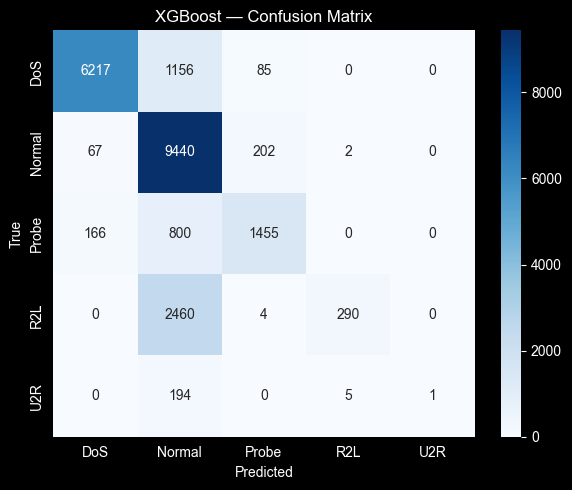

In [7]:
from xgboost import XGBClassifier

model_xgboost = XGBClassifier(
    tree_method= 'hist',
    eval_metric= 'mlogloss',
    verbosity= 0,
    n_jobs= -1,
    random_state= 42
)
xgboost = GridSearchCV(
    estimator= model_xgboost,
    param_grid= {
        'n_estimators': [30, 33, 35],
        'max_depth': [8, 9, 10],
        'learning_rate': [0.1, 0.01],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [3]
    },
    cv= 3,
    scoring= 'f1_macro',
    n_jobs= -1
)

xgboost.fit(X_train, y_train)
print(f'Best params: {xgboost.best_params_}')

y_pred = xgboost.predict(X_test)

label = f"XGBoost"
acc, f1, macro = evaluate(label, y_test, y_pred)
RESULTS[label] = {'Accuracy': acc, 'F1': f1, 'Macro F1': macro}

# filtering models

## Chi2

In [8]:
df_train_chi2 = pd.read_csv(r'../datasets/filtered/KDD_train_chi2.csv')
df_test_chi2 = pd.read_csv(r'../datasets/filtered/KDD_test_chi2.csv')

y_train_chi2 = df_train_chi2['attack']
X_train_chi2 = df_train_chi2.drop(labels= ['attack'], axis= 1).copy()

y_test_chi2 = df_test_chi2['attack']
X_test_chi2 = df_test_chi2.drop(labels= ['attack'], axis= 1).copy()

Best params: {'criterion': 'entropy', 'max_depth': 24, 'n_estimators': 43}

=== Random forest on Chi243) ===
Accuracy : 0.7381 | Precision : 0.7959 | Recall : 0.7381 | Weighted F1 : 0.6971 | Macro F1 : 0.4808
              precision    recall  f1-score   support

         DoS       0.96      0.76      0.85      7458
      Normal       0.64      0.97      0.77      9711
       Probe       0.83      0.58      0.68      2421
         R2L       0.92      0.05      0.09      2754
         U2R       0.17      0.01      0.01       200

    accuracy                           0.74     22544
   macro avg       0.70      0.47      0.48     22544
weighted avg       0.80      0.74      0.70     22544



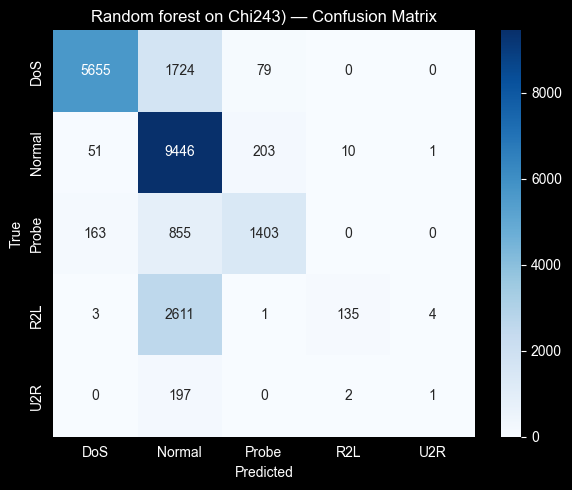

In [9]:
model_rf = RandomForestClassifier(random_state= 42)
random_forest_chi2 = GridSearchCV(
    estimator= model_rf,
    param_grid= {
        "n_estimators" : [43, 44, 45],
        "criterion" : ['entropy', 'gini', 'log_loss'],
        "max_depth": [23, 24, 25],
    },
    cv= 5,
    scoring= 'f1_macro',
    n_jobs= -1
)

random_forest_chi2.fit(X_train_chi2, y_train_chi2)
print(f'Best params: {random_forest_chi2.best_params_}')

y_pred_chi2 = random_forest_chi2.predict(X_test_chi2)

label  = f"Random forest on Chi2{random_forest_chi2.best_params_['n_estimators']})"
acc, f1, macro = evaluate(label, y_test_chi2, y_pred_chi2)
RESULTS[label] = {'Accuracy': acc, 'F1': f1, 'Macro F1': macro}

Best params: {'C': 79, 'coef0': 9, 'gamma': 'scale', 'kernel': 'poly', 'tol': 0.001}

=== SVC in Chi2 ===
Accuracy : 0.7239 | Precision : 0.7652 | Recall : 0.7239 | Weighted F1 : 0.6798 | Macro F1 : 0.4672
              precision    recall  f1-score   support

         DoS       0.90      0.79      0.84      7458
      Normal       0.63      0.92      0.75      9711
       Probe       0.82      0.58      0.68      2421
         R2L       0.86      0.02      0.05      2754
         U2R       0.29      0.01      0.02       200

    accuracy                           0.72     22544
   macro avg       0.70      0.46      0.47     22544
weighted avg       0.77      0.72      0.68     22544



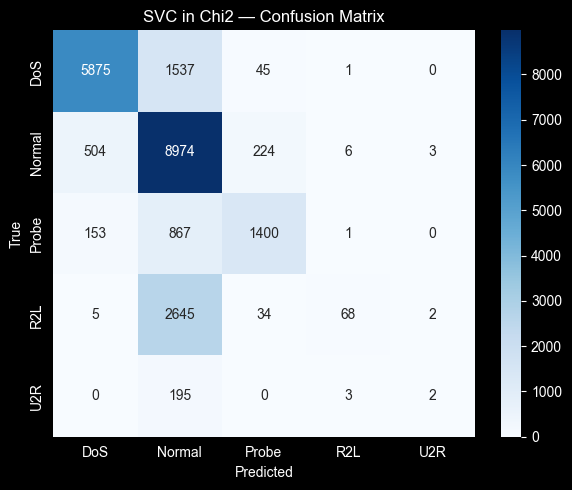

In [10]:
model_svc = SVC()
svc_chi2 = GridSearchCV(
    estimator= model_svc,
    param_grid=  {
        'C': [77, 78, 79],
        'kernel': ['linear', 'poly', 'rbf'],
        'gamma': ['scale'],
        'tol': [1e-3],
        'coef0' : [9]
    },
    cv= 5,
    scoring= 'f1_macro',
    n_jobs= -1
)

svc_chi2.fit(X_train_chi2, y_train_chi2)
print(f'Best params: {svc_chi2.best_params_}')

y_pred_chi2 = svc_chi2.predict(X_test_chi2)

label  = f"SVC in Chi2"
acc, f1, macro = evaluate(label, y_test_chi2, y_pred_chi2)
RESULTS[label] = {'Accuracy': acc, 'F1': f1, 'Macro F1': macro}

Best params: {'learning_rate': 0.15, 'max_depth': 7, 'n_estimators': 88}

=== XGBoost in Chi2 ===
Accuracy : 0.7239 | Precision : 0.7864 | Recall : 0.7239 | Weighted F1 : 0.6805 | Macro F1 : 0.4682
              precision    recall  f1-score   support

         DoS       0.96      0.73      0.83      7458
      Normal       0.62      0.97      0.76      9711
       Probe       0.85      0.56      0.68      2421
         R2L       0.87      0.03      0.06      2754
         U2R       0.40      0.01      0.02       200

    accuracy                           0.72     22544
   macro avg       0.74      0.46      0.47     22544
weighted avg       0.79      0.72      0.68     22544



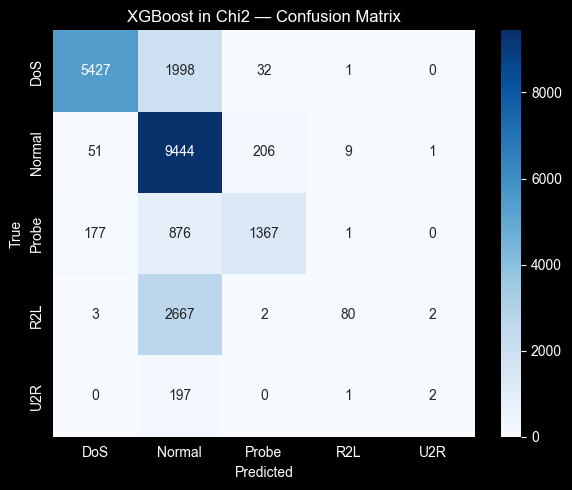

In [11]:
model_xgboost = XGBClassifier(
    tree_method= 'hist',
    eval_metric= 'mlogloss',
    verbosity= 0,
    n_jobs= -1,
    random_state= 42
)
xgboost_chi2 = GridSearchCV(
    estimator= model_xgboost,
    param_grid= {
        'n_estimators': [88, 89, 90],
        'max_depth': [6, 7, 8],
        'learning_rate': [0.15],
    },
    cv= 5,
    scoring= 'f1_macro',
    n_jobs= -1
)

xgboost_chi2.fit(X_train_chi2, y_train_chi2)
print(f'Best params: {xgboost_chi2.best_params_}')

y_pred_chi2 = xgboost_chi2.predict(X_test_chi2)

label = f"XGBoost in Chi2"
acc, f1, macro = evaluate(label, y_test_chi2, y_pred_chi2)
RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

## Mutual info models

In [12]:
df_train_mi = pd.read_csv(r'../datasets/filtered/KDD_train_mi.csv')
df_test_mi = pd.read_csv(r'../datasets/filtered/KDD_test_mi.csv')

y_train_mi = df_train_mi['attack']
X_train_mi = df_train_mi.drop(labels= ['attack'], axis= 1).copy()

y_test_mi = df_test_mi['attack']
X_test_mi = df_test_mi.drop(labels= ['attack'], axis= 1).copy()

Best params: {'criterion': 'gini', 'max_depth': 24, 'n_estimators': 43}

=== Random forest on MI (43) ===
Accuracy : 0.7574 | Precision : 0.7852 | Recall : 0.7574 | Weighted F1 : 0.7065 | Macro F1 : 0.4719
              precision    recall  f1-score   support

         DoS       0.95      0.83      0.89      7458
      Normal       0.66      0.97      0.79      9711
       Probe       0.82      0.58      0.68      2421
         R2L       0.80      0.00      0.00      2754
         U2R       0.00      0.00      0.00       200

    accuracy                           0.76     22544
   macro avg       0.65      0.48      0.47     22544
weighted avg       0.79      0.76      0.71     22544



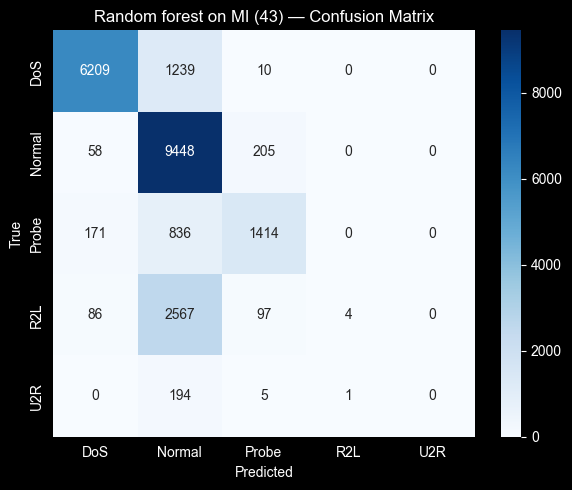

In [13]:
model_rf = RandomForestClassifier(random_state= 42)
random_forest_mi = GridSearchCV(
    estimator= model_rf,
    param_grid= {
        "n_estimators": [43, 44],
        "criterion": ['entropy', 'gini', 'log_loss'],
        "max_depth": [23, 24, 25],
    },
    cv= 5,
    scoring= 'f1_macro',
    n_jobs= -1
)

random_forest_mi.fit(X_train_mi, y_train_mi)
print(f'Best params: {random_forest_mi.best_params_}')

y_pred_mi = random_forest_mi.predict(X_test_mi)

label = f"Random forest on MI ({random_forest_mi.best_params_['n_estimators']})"
acc, f1, macro = evaluate(label, y_test_mi, y_pred_mi)
RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

Best params: {'C': 60, 'gamma': 'scale', 'kernel': 'rbf', 'tol': 0.001}

=== SVC in MI ===
Accuracy : 0.7144 | Precision : 0.7011 | Recall : 0.7144 | Weighted F1 : 0.6649 | Macro F1 : 0.4368
              precision    recall  f1-score   support

         DoS       0.93      0.75      0.83      7458
      Normal       0.63      0.95      0.76      9711
       Probe       0.70      0.52      0.60      2421
         R2L       0.40      0.00      0.00      2754
         U2R       0.00      0.00      0.00       200

    accuracy                           0.71     22544
   macro avg       0.53      0.44      0.44     22544
weighted avg       0.70      0.71      0.66     22544



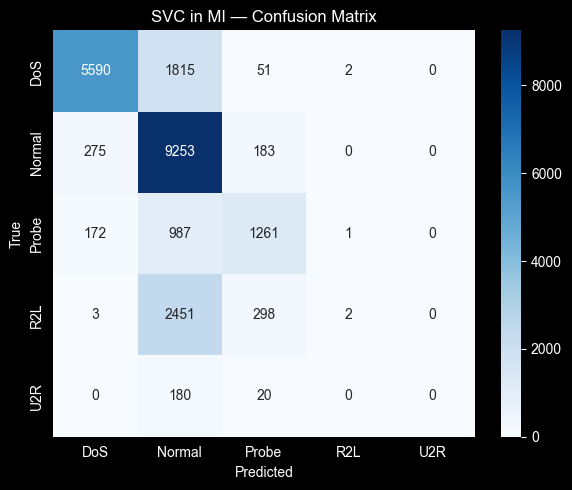

In [14]:
model_svc = SVC()
svc_mi = GridSearchCV(
    estimator= model_svc,
    param_grid= {
        'C': [50, 60],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale'],
        'tol': [1e-3],
    },
    cv= 5,
    scoring= 'f1_macro',
    n_jobs= -1
)
svc_mi.fit(X_train_mi, y_train_mi)
print(f'Best params: {svc_mi.best_params_}')

y_pred_mi = svc_mi.predict(X_test_mi)

label = f"SVC in MI"
acc, f1, macro = evaluate(label, y_test_mi, y_pred_mi)
RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

Best params: {'learning_rate': 0.15, 'max_depth': 6, 'n_estimators': 90}

=== XGBoost in MI ===
Accuracy : 0.7638 | Precision : 0.8193 | Recall : 0.7638 | Weighted F1 : 0.7148 | Macro F1 : 0.4891
              precision    recall  f1-score   support

         DoS       0.96      0.84      0.90      7458
      Normal       0.67      0.97      0.79      9711
       Probe       0.76      0.60      0.67      2421
         R2L       1.00      0.01      0.03      2754
         U2R       1.00      0.03      0.06       200

    accuracy                           0.76     22544
   macro avg       0.88      0.49      0.49     22544
weighted avg       0.82      0.76      0.71     22544



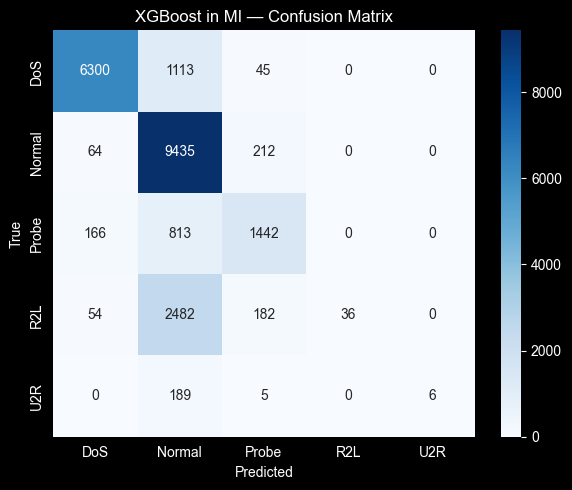

In [15]:
model_xgboost = XGBClassifier(
    tree_method= 'hist',
    eval_metric= 'mlogloss',
    verbosity= 0,
    n_jobs= -1,
    random_state= 42
)
xgboost_mi = GridSearchCV(
    estimator= model_xgboost,
    param_grid= {
        'n_estimators': [88, 89, 90],
        'max_depth': [6, 7, 8],
        'learning_rate': [0.15],
    },
    cv= 5,
    scoring= 'f1_macro',
    n_jobs= -1
)

xgboost_mi.fit(X_train_mi, y_train_mi)
print(f'Best params: {xgboost_mi.best_params_}')

y_pred_mi = xgboost_mi.predict(X_test_mi)

label = f"XGBoost in MI"
acc, f1, macro = evaluate(label, y_test_mi, y_pred_mi)
RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

# Wrapper models:

In [16]:
df_train_rfe_forest = pd.read_csv(r'../datasets/wrappered/KDD_train_rfe_forest.csv')
df_test_rfe_forest = pd.read_csv(r'../datasets/wrappered/KDD_test_rfe_forest.csv')

df_train_sfs_forest = pd.read_csv(r'../datasets/wrappered/KDD_train_sfs_forest.csv')
df_test_sfs_forest = pd.read_csv(r'../datasets/wrappered/KDD_test_sfs_forest.csv')

In [17]:
y_train_rfe_forest = df_train_rfe_forest['attack']
X_train_rfe_forest = df_train_rfe_forest.drop(labels= 'attack', axis= 1).copy()

y_test_rfe_forest = df_test_rfe_forest['attack']
X_test_rfe_forest = df_test_rfe_forest.drop(labels= 'attack', axis= 1).copy()

y_train_sfs_forest = df_train_sfs_forest['attack']
X_train_sfs_forest = df_train_sfs_forest.drop(labels= 'attack', axis= 1).copy()

y_test_sfs_forest = df_test_sfs_forest['attack']
X_test_sfs_forest = df_test_sfs_forest.drop(labels= 'attack', axis= 1).copy()

Best params: {'criterion': 'gini', 'max_depth': 25, 'n_estimators': 41}

=== Random Forest on RFE Forest ===
Accuracy : 0.7599 | Precision : 0.8157 | Recall : 0.7599 | Weighted F1 : 0.7214 | Macro F1 : 0.5011
              precision    recall  f1-score   support

         DoS       0.96      0.81      0.88      7458
      Normal       0.66      0.97      0.78      9711
       Probe       0.87      0.58      0.70      2421
         R2L       1.00      0.08      0.14      2754
         U2R       0.00      0.00      0.00       200

    accuracy                           0.76     22544
   macro avg       0.70      0.49      0.50     22544
weighted avg       0.82      0.76      0.72     22544



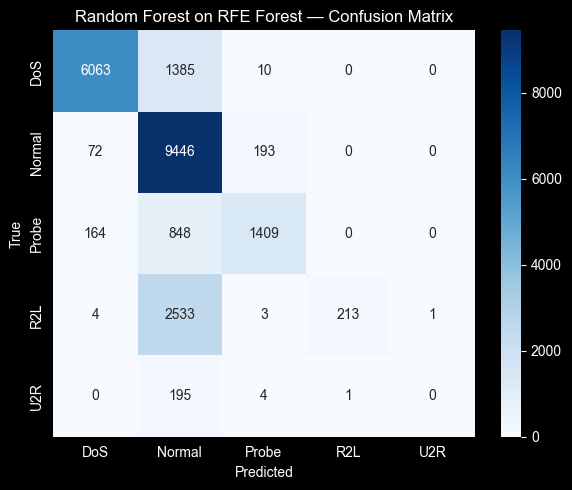

In [18]:
model_rf = RandomForestClassifier(random_state= 42)
random_forest_rfe_forest = GridSearchCV(
    estimator= model_rf,
    param_grid= {
        "n_estimators": [41, 42, 43],
        "criterion": ['entropy', 'gini', 'log_loss'],
        "max_depth": [25],
    },
    cv= 5,
    scoring= 'f1_macro',
    n_jobs= -1
)

random_forest_rfe_forest.fit(X_train_rfe_forest, y_train_rfe_forest)
print(f'Best params: {random_forest_rfe_forest.best_params_}')

y_pred_rfe_forest = random_forest_rfe_forest.predict(X_test_rfe_forest)

label = f"Random Forest on RFE Forest"
acc, f1, macro = evaluate(label, y_test_rfe_forest, y_pred_rfe_forest)
RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

Best params: {'criterion': 'entropy', 'max_depth': 25, 'n_estimators': 42}

=== Random Forest on SFS Forest ===
Accuracy : 0.7663 | Precision : 0.8264 | Recall : 0.7663 | Weighted F1 : 0.7292 | Macro F1 : 0.5217
              precision    recall  f1-score   support

         DoS       0.95      0.79      0.86      7458
      Normal       0.67      0.97      0.79      9711
       Probe       0.88      0.70      0.78      2421
         R2L       1.00      0.08      0.15      2754
         U2R       1.00      0.01      0.02       200

    accuracy                           0.77     22544
   macro avg       0.90      0.51      0.52     22544
weighted avg       0.83      0.77      0.73     22544



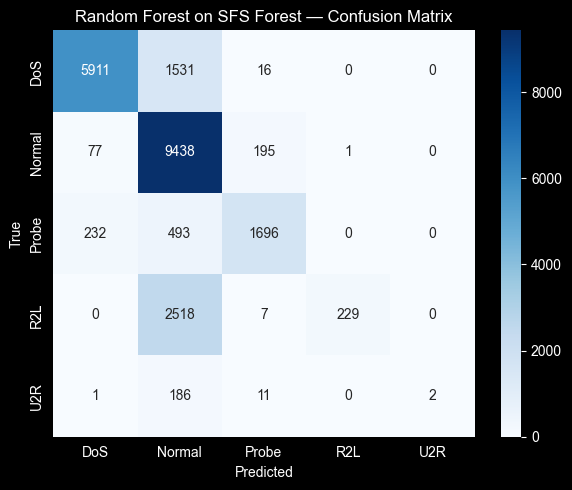

In [19]:
model_rf = RandomForestClassifier(random_state= 42)
random_forest_sfs_forest = GridSearchCV(
    estimator= model_rf,
    param_grid= {
        "n_estimators": [41, 42, 43],
        "criterion": ['entropy', 'gini', 'log_loss'],
        "max_depth": [25],
    },
    cv= 5,
    scoring= 'f1_macro',
    n_jobs= -1
)

random_forest_sfs_forest.fit(X_train_sfs_forest, y_train_sfs_forest)
print(f'Best params: {random_forest_sfs_forest.best_params_}')

y_pred_sfs_forest = random_forest_sfs_forest.predict(X_test_sfs_forest)

label = f"Random Forest on SFS Forest"
acc, f1, macro = evaluate(label, y_test_sfs_forest, y_pred_sfs_forest)
RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

## XGBoost:

In [20]:
df_train_rfe_xgboost = pd.read_csv(r'../datasets/wrappered/KDD_train_rfe_xgboost.csv')
df_test_rfe_xgboost = pd.read_csv(r'../datasets/wrappered/KDD_test_rfe_xgboost.csv')
df_train_sfs_xgboost = pd.read_csv(r'../datasets/wrappered/KDD_train_sfs_xgboost.csv')
df_test_sfs_xgboost = pd.read_csv(r'../datasets/wrappered/KDD_test_sfs_xgboost.csv')

In [21]:
y_train_rfe_xgboost = df_train_rfe_xgboost['attack']
X_train_rfe_xgboost = df_train_rfe_xgboost.drop(labels= 'attack', axis= 1).copy()

y_test_rfe_xgboost = df_test_rfe_xgboost['attack']
X_test_rfe_xgboost = df_test_rfe_xgboost.drop(labels= 'attack', axis= 1).copy()

y_train_sfs_xgboost = df_train_sfs_xgboost['attack']
X_train_sfs_xgboost = df_train_sfs_xgboost.drop(labels= 'attack', axis= 1).copy()

y_test_sfs_xgboost = df_test_sfs_xgboost['attack']
X_test_sfs_xgboost = df_test_sfs_xgboost.drop(labels= 'attack', axis= 1).copy()

Best params: {'learning_rate': 0.15, 'max_depth': 6, 'n_estimators': 90}

=== XGBoost on RFE XGBoost ===
Accuracy : 0.7597 | Precision : 0.8225 | Recall : 0.7597 | Weighted F1 : 0.7100 | Macro F1 : 0.4897
              precision    recall  f1-score   support

         DoS       0.96      0.84      0.89      7458
      Normal       0.66      0.97      0.78      9711
       Probe       0.84      0.60      0.70      2421
         R2L       1.00      0.00      0.00      2754
         U2R       0.88      0.04      0.07       200

    accuracy                           0.76     22544
   macro avg       0.87      0.49      0.49     22544
weighted avg       0.82      0.76      0.71     22544



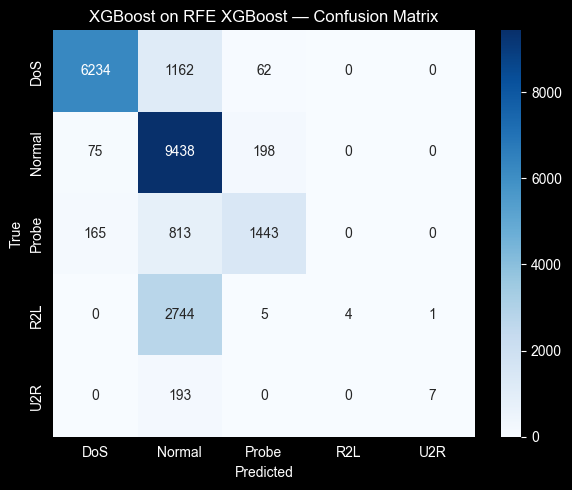

In [22]:
model_xgboost = XGBClassifier(
    tree_method= 'hist',
    eval_metric= 'mlogloss',
    verbosity= 0,
    n_jobs= -1,
    random_state= 42
)
xgboost_rfe_xgboost = GridSearchCV(
    estimator= model_xgboost,
    param_grid= {
        'n_estimators': [88, 89, 90],
        'max_depth': [6, 7, 8],
        'learning_rate': [0.15],
    },
    cv= 5,
    scoring= 'f1_macro',
    n_jobs= -1
)

xgboost_rfe_xgboost.fit(X_train_rfe_xgboost, y_train_rfe_xgboost)
print(f'Best params: {xgboost_rfe_xgboost.best_params_}')

y_pred_rfe_xgboost = xgboost_rfe_xgboost.predict(X_test_rfe_xgboost)

label = f"XGBoost on RFE XGBoost"
acc, f1, macro = evaluate(label, y_test_rfe_xgboost, y_pred_rfe_xgboost)
RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

Best params: {'learning_rate': 0.15, 'max_depth': 8, 'n_estimators': 88}

=== XGBoost on SFS XGBoost ===
Accuracy : 0.7815 | Precision : 0.8027 | Recall : 0.7815 | Weighted F1 : 0.7504 | Macro F1 : 0.5410
              precision    recall  f1-score   support

         DoS       0.96      0.83      0.89      7458
      Normal       0.70      0.97      0.81      9711
       Probe       0.74      0.68      0.71      2421
         R2L       0.79      0.14      0.24      2754
         U2R       0.75      0.03      0.06       200

    accuracy                           0.78     22544
   macro avg       0.79      0.53      0.54     22544
weighted avg       0.80      0.78      0.75     22544



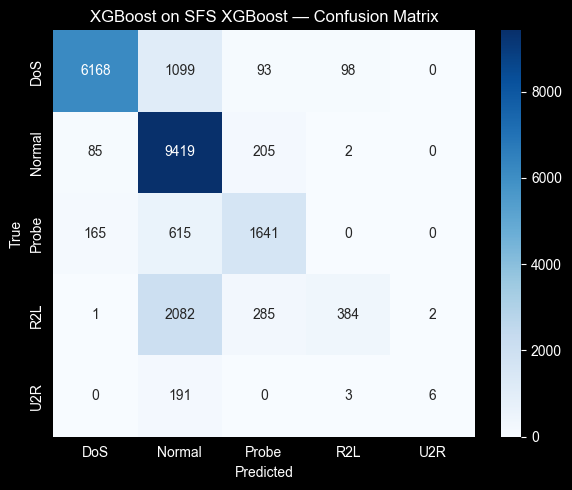

In [23]:
model_xgboost = XGBClassifier(
    tree_method= 'hist',
    eval_metric= 'mlogloss',
    verbosity= 0,
    n_jobs= -1,
    random_state= 42
)
xgboost_sfs_xgboost = GridSearchCV(
    estimator= model_xgboost,
    param_grid= {
        'n_estimators': [88, 89, 90],
        'max_depth': [6, 7, 8],
        'learning_rate': [0.15],
    },
    cv= 5,
    scoring= 'f1_macro',
    n_jobs= -1
)

xgboost_sfs_xgboost.fit(X_train_sfs_xgboost, y_train_sfs_xgboost)
print(f'Best params: {xgboost_sfs_xgboost.best_params_}')

y_pred_sfs_xgboost = xgboost_sfs_xgboost.predict(X_test_sfs_xgboost)

label = f"XGBoost on SFS XGBoost"
acc, f1, macro = evaluate(label, y_test_sfs_xgboost, y_pred_sfs_xgboost)
RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

## SVC

In [24]:
df_train_rfe_svc = pd.read_csv(r'../datasets/wrappered/KDD_train_rfe_svc.csv')
df_test_rfe_svc = pd.read_csv(r'../datasets/wrappered/KDD_test_rfe_svc.csv')
df_train_sfs_svc = pd.read_csv(r'../datasets/wrappered/KDD_train_sfs_svc.csv')
df_test_sfs_svc = pd.read_csv(r'../datasets/wrappered/KDD_test_sfs_svc.csv')

In [25]:
y_train_rfe_svc = df_train_rfe_svc['attack']
X_train_rfe_svc = df_train_rfe_svc.drop(labels= 'attack', axis= 1).copy()

y_test_rfe_svc = df_test_rfe_svc['attack']
X_test_rfe_svc = df_test_rfe_svc.drop(labels= 'attack', axis= 1).copy()

y_train_sfs_svc = df_train_sfs_svc['attack']
X_train_sfs_svc = df_train_sfs_svc.drop(labels= 'attack', axis= 1).copy()

y_test_sfs_svc = df_test_sfs_svc['attack']
X_test_sfs_svc = df_test_sfs_svc.drop(labels= 'attack', axis= 1).copy()

Best params: {'C': 5, 'kernel': 'linear', 'tol': 0.01}

=== SVC on RFE SVC ===
Accuracy : 0.7178 | Precision : 0.7553 | Recall : 0.7178 | Weighted F1 : 0.6843 | Macro F1 : 0.4819
              precision    recall  f1-score   support

         DoS       0.86      0.74      0.80      7458
      Normal       0.64      0.93      0.76      9711
       Probe       0.79      0.56      0.65      2421
         R2L       0.91      0.11      0.20      2754
         U2R       0.00      0.00      0.00       200

    accuracy                           0.72     22544
   macro avg       0.64      0.47      0.48     22544
weighted avg       0.76      0.72      0.68     22544



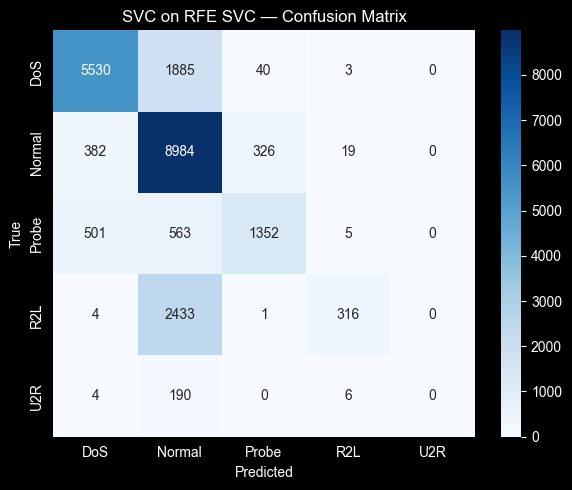

In [26]:
model_svc = SVC(cache_size= 1000)
svc_rfe_svc = GridSearchCV(
    estimator= model_svc,
    param_grid= {
        'C': [1, 5],
        'kernel': ['linear'],
        'tol': [1e-2]
    },
    cv= 3,
    scoring= 'f1_macro',
    n_jobs= -1
)

svc_rfe_svc.fit(X_train_rfe_svc, y_train_rfe_svc)
print(f'Best params: {svc_rfe_svc.best_params_}')

y_pred_rfe_svc = svc_rfe_svc.predict(X_test_rfe_svc)

label = f"SVC on RFE SVC"
acc, f1, macro = evaluate(label, y_test_rfe_svc, y_pred_rfe_svc)
RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

Best params: {'C': 1, 'kernel': 'linear', 'tol': 0.1}

=== SVC on SFS SVC ===
Accuracy : 0.7416 | Precision : 0.7881 | Recall : 0.7416 | Weighted F1 : 0.7075 | Macro F1 : 0.4856
              precision    recall  f1-score   support

         DoS       0.97      0.82      0.88      7458
      Normal       0.65      0.93      0.76      9711
       Probe       0.67      0.56      0.61      2421
         R2L       0.97      0.10      0.17      2754
         U2R       0.00      0.00      0.00       200

    accuracy                           0.74     22544
   macro avg       0.65      0.48      0.49     22544
weighted avg       0.79      0.74      0.71     22544



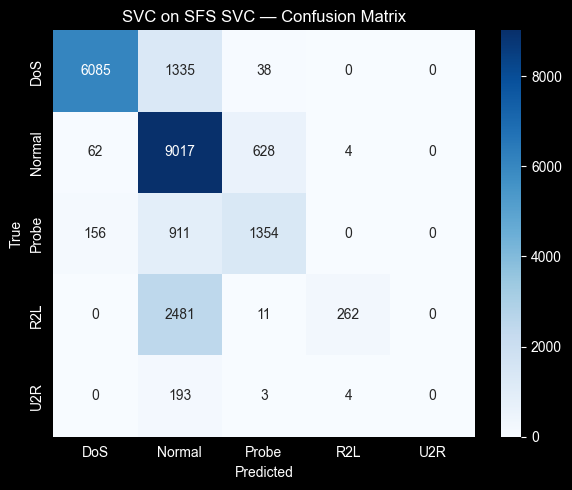

In [27]:
model_svc = SVC(cache_size= 1000)
svc_sfs_svc = GridSearchCV(
    estimator= model_svc,
    param_grid= {
        'C': [1],
        'kernel': ['linear'],
        'tol': [1e-1]
    },
    cv= 2,
    scoring= 'f1_macro',
    n_jobs= -1
)

svc_sfs_svc.fit(X_train_sfs_svc, y_train_sfs_svc)
print(f'Best params: {svc_sfs_svc.best_params_}')

y_pred_sfs_svc = svc_sfs_svc.predict(X_test_sfs_svc)

label = f"SVC on SFS SVC"
acc, f1, macro = evaluate(label, y_test_sfs_svc, y_pred_sfs_svc)
RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}